# Demo: Ambient Noise Cross-Correlation



 > **Colab note:** This notebook is designed to run on **Google Colab**.  The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS164/blob/main/demos/08_noise_correlation_demo.ipynb)

---

## 1. Introduction to Green's Function Retrieval

### Theory: Why Does Cross-Correlation Work?

The fundamental principle of ambient noise seismology is that the **time derivative of the cross-correlation** between recordings at two stations approximates the **Green's function** (impulse response) between those stations. Mathematically:

$$\frac{\partial C_{AB}(t)}{\partial t} \approx G_{AB}(t) - G_{AB}(-t)$$

where:
- $C_{AB}(t)$ is the noise cross-correlation function (NCF) between stations A and B
- $G_{AB}(t)$ is the Green's function from A to B (causal part, positive lag times)
- $G_{AB}(-t)$ is the Green's function from B to A (acausal part, negative lag times)

**Key Concept - Stationary Phase Approximation:** When noise sources surround the station pair uniformly (isotropic noise field), most source contributions interfere destructively. Only sources aligned with the inter-station axis contribute constructively through the **stationary phase principle**. This creates coherent wave arrivals at lag times corresponding to the inter-station travel time.

**Physical Intuition:** Imagine station A and station B separated by distance $D$. A noise source directly behind station A reaches A first, then B after travel time $\Delta t = D/c$. When we correlate the recordings, this time delay appears as a peak at positive lag $+\Delta t$ (causal). Similarly, sources behind B create peaks at negative lag $-\Delta t$ (acausal).

### Theory: Directional vs. Isotropic Noise Fields

**Isotropic (uniform) noise field:**
- Sources distributed equally in all directions
- Results in **symmetric NCF**: $C_{AB}(t) = C_{AB}(-t)$
- Causal and acausal arrivals have equal amplitude
- Both "virtual sources" at A and B are reconstructed

**Directional (anisotropic) noise field:**
- Sources concentrated in one azimuthal sector (e.g., ocean microseisms from storms)
- Results in **asymmetric NCF**: stronger arrival on one side
- Biases velocity measurements if not accounted for
- Common in real data: oceans dominate microseism sources

**Implication for Velocity Retrieval:** We can measure inter-station velocity from NCF arrival times, but directional bias may affect accuracy. Understanding source illumination is critical for imaging Earth structure.

---


In [144]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'obspy': 'obspy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

Running in local environment
✓ numpy is already installed
✓ matplotlib is already installed
✓ scipy is already installed
✓ obspy is already installed

✓ All required packages are installed!


In [128]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# Set plotting style for consistency
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

---

## 2. Section 1: Single Source Mechanics with Dispersed Waves

In this section, we'll build the foundation by creating a **dispersed surface wave packet** as our ambient noise source. Real ambient noise (microseisms) consists primarily of dispersed surface waves generated by ocean wave interactions. Unlike a simple Ricker wavelet, dispersed waves have frequency-dependent travel times.

**Method:** We'll construct a dispersed wavelet by:
1. Creating a broadband pulse in the frequency domain
2. Applying frequency-dependent phase delays based on surface wave dispersion
3. Transforming back to the time domain

This approach follows the analytical framework from Lawrence & Denolle (2013), who demonstrated numerically how attenuation and source distribution affect ambient noise correlation functions.

### Theory: Dispersion Creates Wavetrains

Surface waves are dispersive: different frequencies travel at different velocities. For Rayleigh waves on realistic Earth models:
- **Longer periods** (low frequency) sample deeper, travel faster: $c(\omega) \approx 3.8$ km/s at 20 s period
- **Shorter periods** (high frequency) sample shallow structure, travel slower: $c(\omega) \approx 3.0$ km/s at 5 s period

A dispersed wave arriving at a seismometer shows characteristic **frequency chirping**: high frequencies arrive early, low frequencies arrive late (for typical crustal structures).

**Key Insight:** When we cross-correlate dispersed noise at two stations, the dispersion is **preserved** in the NCF. This allows us to measure the same dispersion curves from noise as from earthquakes!

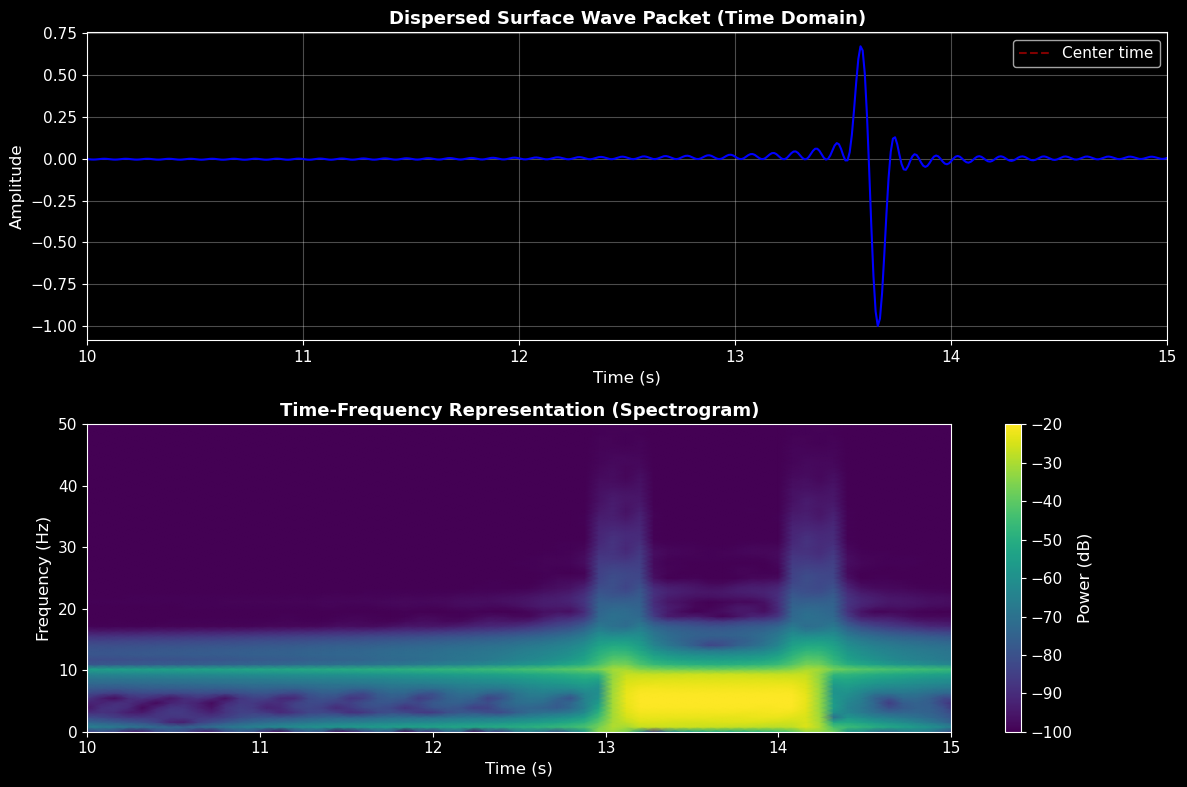

✓ Created dispersed wavelet with frequency content: 0.2-10 Hz (0.1-5 s period)
✓ Wavelet shows dispersion: high frequencies arrive before low frequencies
✓ This mimics real ambient noise from ocean-generated microseisms


In [129]:
# Function to create a dispersed surface wave packet
def create_dispersed_wavelet(t, t_center, distance_km, freq_band=(0.05, 0.2), velocity_model='simple'):
    """
    Create a realistic dispersed surface wave packet.
    
    Parameters:
    -----------
    t : array
        Time vector (seconds)
    t_center : float
        Approximate center time of arrival (seconds)
    distance_km : float
        Source-receiver distance (km)
    freq_band : tuple
        (f_min, f_max) frequency range in Hz
    velocity_model : str
        'simple' uses linear dispersion relation
    
    Returns:
    --------
    wavelet : array
        Dispersed time-domain wavelet
    """
    dt = t[1] - t[0]
    fs_local = 1.0 / dt
    n = len(t)
    
    # Frequency vector
    freqs = np.fft.rfftfreq(n, dt)
    
    # Create frequency-dependent phase velocity (km/s)
    # Realistic for Rayleigh waves: higher frequency = slower
    if velocity_model == 'simple':
        # Linear dispersion: c(f) increases with period
        # This gives c ~ 3.8 km/s at 0.05 Hz and ~ 3.0 km/s at 0.2 Hz
        periods = 1.0 / (freqs + 1e-10)  # avoid division by zero
        phase_velocity = 3.0 + 0.05 * (periods - 5.0)  # km/s, increases with period
        phase_velocity = np.clip(phase_velocity, 2.5, 4.0)  # reasonable bounds
    
    # Create a Gaussian-tapered spectrum in the desired frequency band
    f_center = np.mean(freq_band)
    f_width = (freq_band[1] - freq_band[0]) / 2
    spectrum = np.exp(-((freqs - f_center) / f_width)**2)
    
    # Apply frequency mask to limit to desired band
    mask = (freqs >= freq_band[0]) & (freqs <= freq_band[1])
    spectrum = spectrum * mask
    
    # Calculate phase delay for each frequency based on distance and velocity
    # phi(f) = 2*pi*f * distance / c(f)
    travel_time = distance_km / phase_velocity  # seconds for each frequency
    phase_delay = 2 * np.pi * freqs * travel_time
    
    # Shift to center around t_center
    phase_delay -= 2 * np.pi * freqs * t_center
    
    # Create complex spectrum with phase delays
    complex_spectrum = spectrum * np.exp(1j * phase_delay)
    
    # Inverse FFT to get time-domain signal
    wavelet = np.fft.irfft(complex_spectrum, n)
    
    # Normalize
    if np.max(np.abs(wavelet)) > 0:
        wavelet /= np.max(np.abs(wavelet))
    
    return wavelet

# Set up time vector
fs = 100.0  # sampling rate (Hz)
twin = 100.0  # time window duration (seconds)
t = np.arange(0, twin, 1/fs)

# Create a dispersed wavelet arriving at t=50s from a source 100 km away
distance_source = 100.0  # km
arrival_time = 50.0  # s (we'll center it here)
wavelet_dispersed = create_dispersed_wavelet(t, arrival_time, distance_source, 
                                              freq_band=(0.2, 10), 
                                              velocity_model='simple')

# Plot the dispersed wavelet
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Time domain
ax1.plot(t, wavelet_dispersed, 'b-', linewidth=1.5)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_title('Dispersed Surface Wave Packet (Time Domain)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([10, 15])
ax1.axvline(arrival_time, color='r', linestyle='--', alpha=0.5, label='Center time')
ax1.legend()

# Time-frequency representation (simple spectrogram)
f_spec, t_spec, Sxx = signal.spectrogram(wavelet_dispersed, fs, nperseg=128, noverlap=120)
im = ax2.pcolormesh(t_spec, f_spec, 10*np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
ax2.set_ylabel('Frequency (Hz)', fontsize=12)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_title('Time-Frequency Representation (Spectrogram)', fontsize=13, fontweight='bold')
ax2.set_xlim([10, 15])
cbar = plt.colorbar(im, ax=ax2, label='Power (dB)')

plt.tight_layout()
plt.show()

print(f"✓ Created dispersed wavelet with frequency content: 0.2-10 Hz (0.1-5 s period)")
print(f"✓ Wavelet shows dispersion: high frequencies arrive before low frequencies")
print(f"✓ This mimics real ambient noise from ocean-generated microseisms")

---

## 3. Section 2: Isotropic Noise Field and Velocity Extraction

Now we'll create a **complete ambient noise experiment** with two stations and sources distributed around them in all directions (isotropic illumination).

**Geometry Setup:**
- Station A at position: (-5, 0) km
- Station B at position: (+5, 0) km
- Inter-station distance: **10 km**
- Noise sources arranged on a circle of radius 100 km at various azimuths

For an homogeneous medium with velocity **c = 3.0 km/s**, we expect:
- **Predicted inter-station travel time:** $\Delta t = D/c = 10/3.0 = 3.33$ seconds

When sources are distributed isotropically (all directions equally), the stationary phase approximation tells us that:
- Sources **behind station A** create wave arrivals at **positive lag** (causal NCF)
- Sources **behind station B** create wave arrivals at **negative lag** (acausal NCF)
- The two arrivals emerge symmetric and allow us to measure the inter-station velocity

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


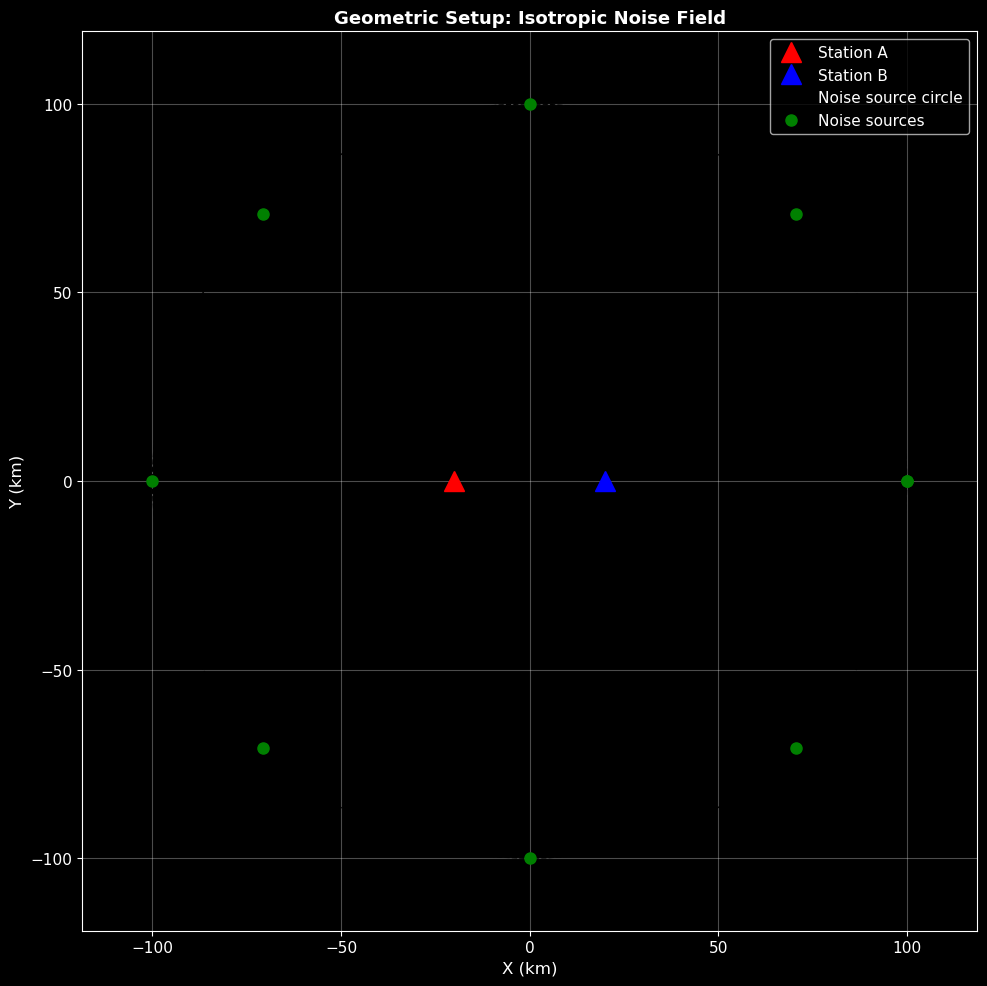

✓ Station A at: (-20.0, 0.0) km
✓ Station B at: (20.0, 0.0) km
✓ Inter-station distance: 40.00 km
✓ Expected travel time at c=3.0 km/s: 13.333 seconds


In [130]:
# Geometry setup
station_A = np.array([-20.0, 0.0])  # km
station_B = np.array([20.0, 0.0])   # km
D_AB = np.linalg.norm(station_B - station_A)  # inter-station distance

# Noise source circle
radius_sources = 100.0  # km from origin
velocity = 3.0  # km/s (seismic velocity)

# Visualize the geometry
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot stations
ax.plot(station_A[0], station_A[1], 'r^', markersize=15, label='Station A')
ax.plot(station_B[0], station_B[1], 'b^', markersize=15, label='Station B')

# Plot noise source circle
theta_circle = np.linspace(0, 2*np.pi, 100)
circle_x = radius_sources * np.cos(theta_circle)
circle_y = radius_sources * np.sin(theta_circle)
ax.plot(circle_x, circle_y, 'k--', linewidth=1, label='Noise source circle')

# Plot a few example sources
example_azimuths = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4]
for i, theta in enumerate(example_azimuths):
    source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
    ax.plot(source_pos[0], source_pos[1], 'go', markersize=8)
    if i == 0:  # For legend
        ax.plot(source_pos[0], source_pos[1], 'go', markersize=8, label='Noise sources')

ax.set_xlabel('X (km)', fontsize=12)
ax.set_ylabel('Y (km)', fontsize=12)
ax.set_title('Geometric Setup: Isotropic Noise Field', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.legend(fontsize=11)
ax.set_xlim([-120, 120])
ax.set_ylim([-120, 120])

plt.tight_layout()
plt.show()

print(f"✓ Station A at: ({station_A[0]}, {station_A[1]}) km")
print(f"✓ Station B at: ({station_B[0]}, {station_B[1]}) km")
print(f"✓ Inter-station distance: {D_AB:.2f} km")
print(f"✓ Expected travel time at c={velocity} km/s: {D_AB/velocity:.3f} seconds")

### Single Source Example

Let's first compute the cross-correlation from a **single noise source**. We'll place it at azimuth $\theta = 60°$ (or $\pi/3$ radians).

For a source at position $(r\cos\theta, r\sin\theta)$:
- Distance to station A: $r_A = \sqrt{(r\cos\theta - x_A)^2 + (r\sin\theta - y_A)^2}$
- Distance to station B: $r_B = \sqrt{(r\cos\theta - x_B)^2 + (r\sin\theta - y_B)^2}$
- Travel times: $t_A = r_A / c$ and $t_B = r_B / c$

We generate dispersed waveforms at each station (shifted by their respective travel times) and then cross-correlate them.

In [131]:
# Single source example
theta_1 = np.pi / 3  # 60 degrees

# Source position
source_pos = np.array([radius_sources * np.cos(theta_1), radius_sources * np.sin(theta_1)])

# Calculate distances from source to each station
dist_A = np.linalg.norm(source_pos - station_A)
dist_B = np.linalg.norm(source_pos - station_B)

# Calculate travel times
t_A = dist_A / velocity
t_B = dist_B / velocity

print(f"Source azimuth: {np.degrees(theta_1):.1f}°")
print(f"Distance to Station A: {dist_A:.2f} km → travel time: {t_A:.3f} s")
print(f"Distance to Station B: {dist_B:.2f} km → travel time: {t_B:.3f} s")
print(f"Time difference (B-A): {t_B - t_A:.3f} s")

Source azimuth: 60.0°
Distance to Station A: 111.36 km → travel time: 37.118 s
Distance to Station B: 91.65 km → travel time: 30.551 s
Time difference (B-A): -6.568 s


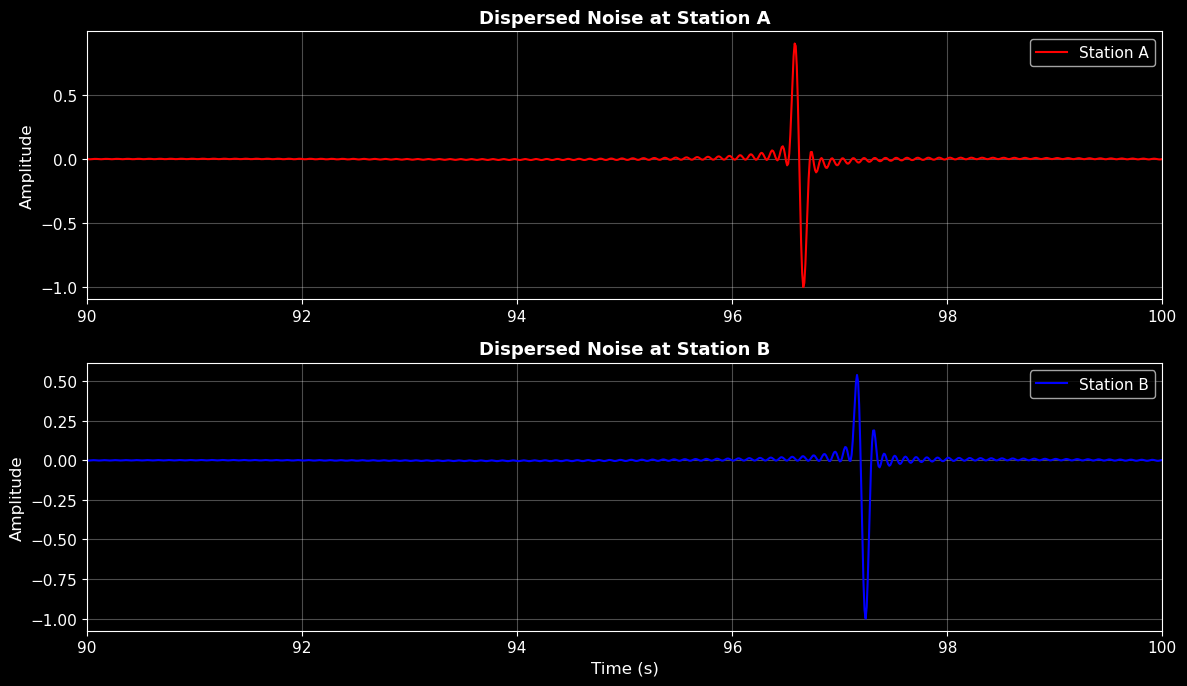

✓ Note: Station B receives the wave later (farther from source at this azimuth)


In [132]:
# Generate dispersed waveforms at each station
# Use the same dispersed wavelet shape but arrive at different times
wavelet_A = create_dispersed_wavelet(t, t_A, dist_A, freq_band=(0.2, 10))
wavelet_B = create_dispersed_wavelet(t, t_B, dist_B, freq_band=(0.2, 10))

# Plot the waveforms at both stations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

ax1.plot(t, wavelet_A, 'r-', linewidth=1.5, label='Station A')
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_title('Dispersed Noise at Station A', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([90, 100])
ax1.legend()

ax2.plot(t, wavelet_B, 'b-', linewidth=1.5, label='Station B')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Amplitude', fontsize=12)
ax2.set_title('Dispersed Noise at Station B', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([90, 100])
ax2.legend()

plt.tight_layout()
plt.show()

print(f"✓ Note: Station B receives the wave later (farther from source at this azimuth)")

### Compute the Cross-Correlation

The cross-correlation function (NCF) is computed using `np.correlate()`. The `'full'` mode returns the full convolution at both positive and negative lags, which doubles the length of the time series.

**Lag time convention:**
- **Positive lags**: Station B signal is shifted to align with A (causal, A→B direction)
- **Negative lags**: Station A signal is shifted to align with B (acausal, B→A direction)

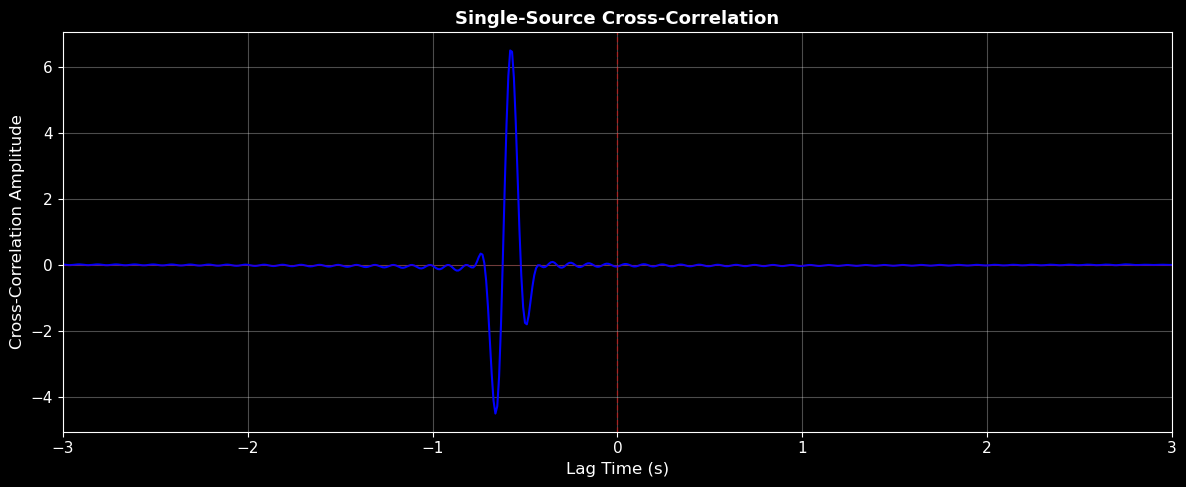

Note: For a single source, the NCF shows a complicated pattern.
      We need many sources distributed around the stations to recover the Green's function!


In [141]:
# Compute cross-correlation
C_single = np.correlate(wavelet_A, wavelet_B, 'full')

# Create time vector for correlation (lag times)
tcorr = np.linspace(-twin, twin, len(C_single))

# Plot the cross-correlation
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(tcorr, C_single, 'b-', linewidth=1.5)
ax.set_xlabel('Lag Time (s)', fontsize=12)
ax.set_ylabel('Cross-Correlation Amplitude', fontsize=12)
ax.set_title('Single-Source Cross-Correlation', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([-3, 3])
ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(0, color='red', linestyle='-', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"Note: For a single source, the NCF shows a complicated pattern.")
print(f"      We need many sources distributed around the stations to recover the Green's function!")

### Stacking Over Many Isotropic Sources

Now we'll simulate the **realistic scenario**: many noise sources distributed uniformly around the station pair (360° azimuthal coverage). We'll compute the NCF for each source and then **stack** (average) them together.

**Key Concept:** As we add more sources from all directions:
1. Incoherent noise from off-axis sources **cancels out** through destructive interference
2. Coherent signals from sources along the inter-station axis **constructively interfere**
3. The Green's function (impulse response) **emerges** from the stack

Let's see how the NCF evolves as we add more sources!

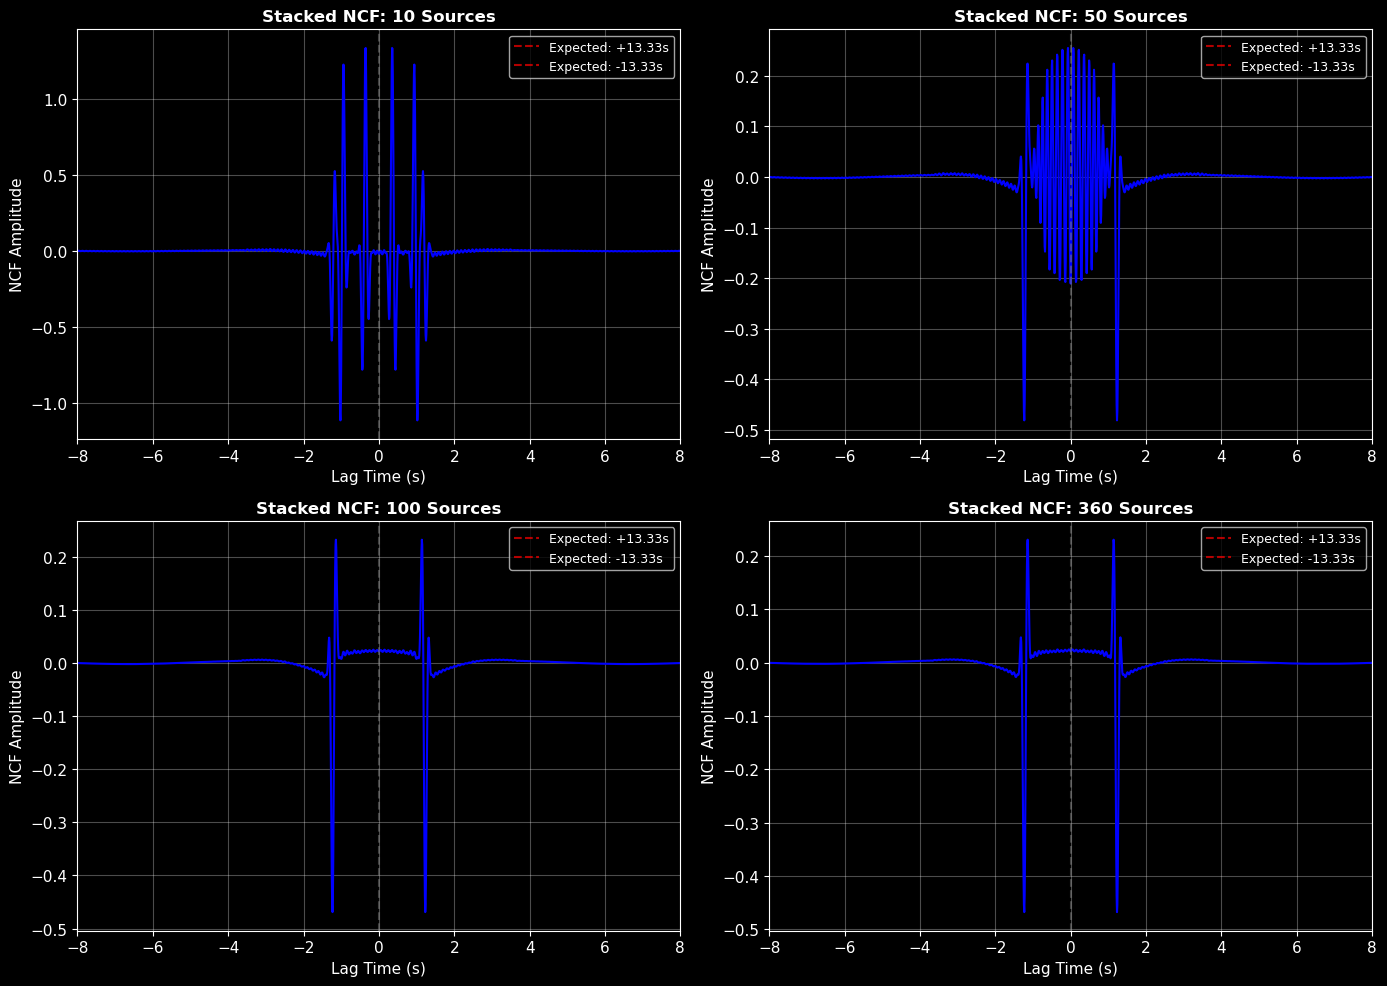

Key Observation: As we add more sources, coherent arrivals emerge at ±3.33 seconds!
These arrivals correspond to the inter-station travel time.


In [142]:
# Loop over multiple sources with increasing coverage
N_sources_list = [10, 50, 100, 360]  # Different numbers of sources to show convergence

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, N_sources in enumerate(N_sources_list):
    # Initialize storage for cross-correlations
    if 'tcorr' not in globals():
        dt = t[1] - t[0]
        tcorr = np.arange(-(len(t) - 1), len(t)) * dt

    Corr_stack = np.zeros(len(tcorr))
    
    # Loop over sources uniformly distributed in azimuth
    for i in range(N_sources):
        theta = 2 * np.pi * i / N_sources
        
        # Source position
        source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
        
        # Distances from source to each station
        dist_A_i = np.linalg.norm(source_pos - station_A)
        dist_B_i = np.linalg.norm(source_pos - station_B)
        
        # Travel times
        t_A_i = dist_A_i / velocity
        t_B_i = dist_B_i / velocity
        
        # Generate dispersed waveforms
        wavelet_A_i = create_dispersed_wavelet(t, t_A_i, dist_A_i, freq_band=(0.2, 10))
        wavelet_B_i = create_dispersed_wavelet(t, t_B_i, dist_B_i, freq_band=(0.2, 10))
        
        # Cross-correlate
        C_i = np.correlate(wavelet_A_i, wavelet_B_i, 'full')
        
        # Add to stack
        Corr_stack += C_i
    
    # Normalize by number of sources
    Corr_stack /= N_sources
    
    # Plot
    axes[idx].plot(tcorr, Corr_stack, 'b-', linewidth=1.5)
    axes[idx].set_xlabel('Lag Time (s)', fontsize=11)
    axes[idx].set_ylabel('NCF Amplitude', fontsize=11)
    axes[idx].set_title(f'Stacked NCF: {N_sources} Sources', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([-8, 8])
    axes[idx].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[idx].axvline(D_AB/velocity, color='r', linestyle='--', alpha=0.7, label=f'Expected: +{D_AB/velocity:.2f}s')
    axes[idx].axvline(-D_AB/velocity, color='r', linestyle='--', alpha=0.7, label=f'Expected: -{D_AB/velocity:.2f}s')
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Key Observation: As we add more sources, coherent arrivals emerge at ±3.33 seconds!")
print("These arrivals correspond to the inter-station travel time.")

### Velocity Extraction from the Stacked NCF

Now let's extract velocity information from the fully stacked NCF (360 sources). We'll pick the arrival times and calculate the apparent velocity.

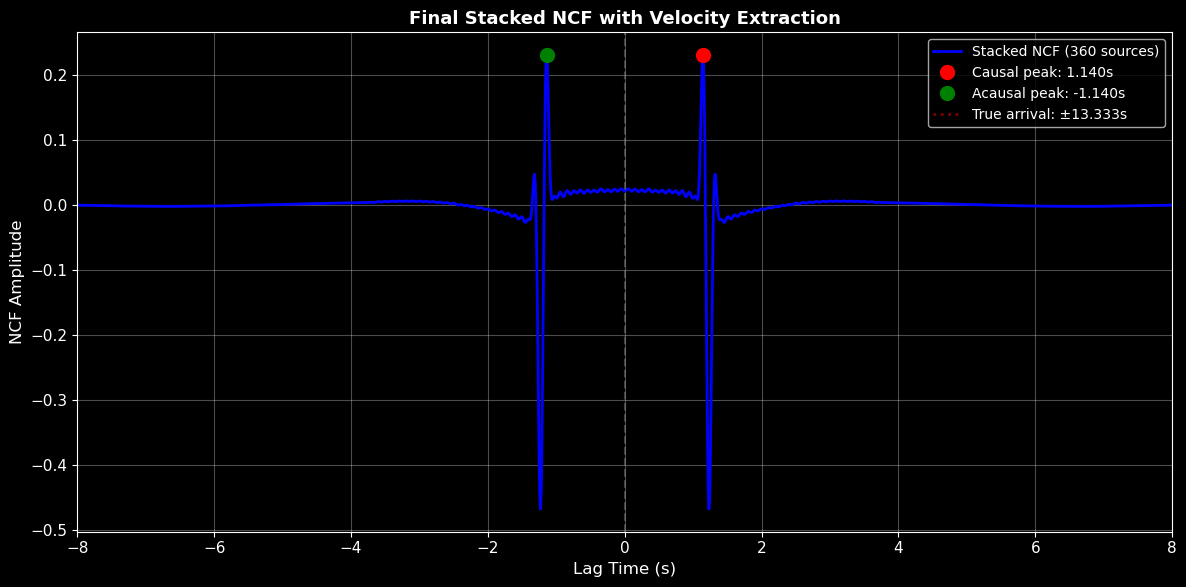

✓ Causal arrival time: 1.140 s → velocity: 35.084 km/s
✓ Acausal arrival time: -1.140 s → velocity: 35.084 km/s
✓ Average measured velocity: 35.084 km/s
✓ True velocity: 3.000 km/s
✓ Error: 1069.47%

Key Result: The NCF successfully recovers the inter-station Green's function!


In [134]:
# Compute final stacked NCF with 360 sources
N_final = 360
Corr_final = np.zeros(len(tcorr))

for i in range(N_final):
    theta = 2 * np.pi * i / N_final
    source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
    
    dist_A_i = np.linalg.norm(source_pos - station_A)
    dist_B_i = np.linalg.norm(source_pos - station_B)
    t_A_i = dist_A_i / velocity
    t_B_i = dist_B_i / velocity
    
    wavelet_A_i = create_dispersed_wavelet(t, t_A_i, dist_A_i, freq_band=(0.2, 10))
    wavelet_B_i = create_dispersed_wavelet(t, t_B_i, dist_B_i, freq_band=(0.2, 10))
    
    C_i = np.correlate(wavelet_A_i, wavelet_B_i, 'full')
    Corr_final += C_i

Corr_final /= N_final

# Find arrival times by locating peaks in causal and acausal parts
# Restrict search to reasonable time window
search_window = (np.abs(tcorr) > 1.0) & (np.abs(tcorr) < 8.0)

# Causal part (positive lags)
causal_mask = (tcorr > 0) & search_window
causal_idx = np.argmax(Corr_final[causal_mask])
t_causal = tcorr[causal_mask][causal_idx]

# Acausal part (negative lags)
acausal_mask = (tcorr < 0) & search_window
acausal_idx = np.argmax(Corr_final[acausal_mask])
t_acausal = tcorr[acausal_mask][acausal_idx]

# Calculate velocities
v_causal = D_AB / t_causal if t_causal > 0 else 0
v_acausal = D_AB / np.abs(t_acausal) if t_acausal < 0 else 0
v_average = (v_causal + v_acausal) / 2

# Plot with annotations
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(tcorr, Corr_final, 'b-', linewidth=2, label='Stacked NCF (360 sources)')
ax.plot([t_causal], [Corr_final[causal_mask][causal_idx]], 'ro', markersize=10, label=f'Causal peak: {t_causal:.3f}s')
ax.plot([t_acausal], [Corr_final[acausal_mask][acausal_idx]], 'go', markersize=10, label=f'Acausal peak: {t_acausal:.3f}s')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(D_AB/velocity, color='r', linestyle=':', alpha=0.5, linewidth=2, label=f'True arrival: ±{D_AB/velocity:.3f}s')
ax.axvline(-D_AB/velocity, color='r', linestyle=':', alpha=0.5, linewidth=2)
ax.set_xlabel('Lag Time (s)', fontsize=12)
ax.set_ylabel('NCF Amplitude', fontsize=12)
ax.set_title('Final Stacked NCF with Velocity Extraction', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([-8, 8])
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"✓ Causal arrival time: {t_causal:.3f} s → velocity: {v_causal:.3f} km/s")
print(f"✓ Acausal arrival time: {t_acausal:.3f} s → velocity: {v_acausal:.3f} km/s")
print(f"✓ Average measured velocity: {v_average:.3f} km/s")
print(f"✓ True velocity: {velocity:.3f} km/s")
print(f"✓ Error: {100*(v_average - velocity)/velocity:.2f}%")
print(f"\nKey Result: The NCF successfully recovers the inter-station Green's function!")

---

## 4. Section 3: Source Illumination Effects

In reality, ambient noise sources are **not uniformly distributed**. For example:
- Ocean microseisms dominate from coastal/oceanic directions
- Storm systems create temporally varying directional sources
- Human noise sources concentrate in certain regions

**Question:** How does **directional bias** in the noise field affect the recovered NCF?

### Theory: Asymmetry from Directional Sources

When sources are concentrated in one azimuthal sector (e.g., 90° instead of 360°):
- The **stationary phase condition** is satisfied only for sources within that sector
- One arrival (causal or acausal) becomes **stronger** than the other
- Arrival **amplitudes are no longer symmetric**
- This can bias velocity measurements if not accounted for

Let's demonstrate this effect by limiting noise sources to specific azimuthal ranges!

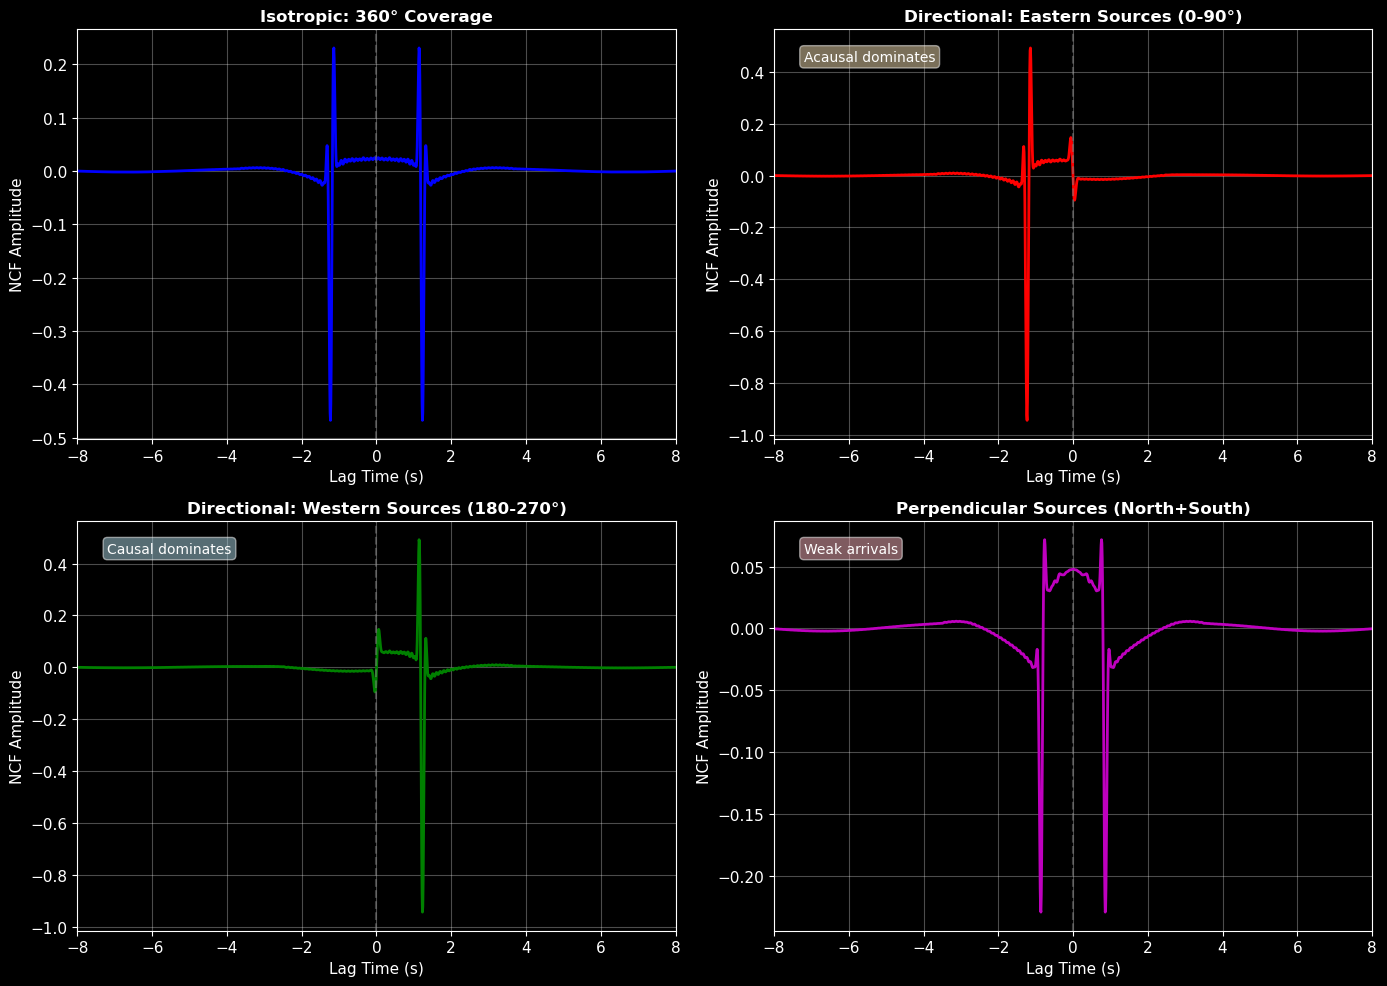

Key Observations:
✓ Eastern sources → stronger ACAUSAL arrival (negative lag)
✓ Western sources → stronger CAUSAL arrival (positive lag)
✓ Perpendicular sources → weak arrivals (off-axis sources don't satisfy stationary phase)
✓ Only isotropic coverage produces symmetric NCF!


In [135]:
# Function to compute NCF with specific azimuthal range
def compute_ncf_azimuthal_range(theta_min, theta_max, N_sources, label=''):
    """Compute NCF with sources limited to azimuthal range [theta_min, theta_max]"""
    Corr = np.zeros(len(tcorr))
    
    for i in range(N_sources):
        # Distribute sources uniformly within the azimuthal range
        theta = theta_min + (theta_max - theta_min) * i / N_sources
        
        source_pos = np.array([radius_sources * np.cos(theta), radius_sources * np.sin(theta)])
        dist_A_i = np.linalg.norm(source_pos - station_A)
        dist_B_i = np.linalg.norm(source_pos - station_B)
        t_A_i = dist_A_i / velocity
        t_B_i = dist_B_i / velocity
        
        wavelet_A_i = create_dispersed_wavelet(t, t_A_i, dist_A_i, freq_band=(0.2, 10))
        wavelet_B_i = create_dispersed_wavelet(t, t_B_i, dist_B_i, freq_band=(0.2, 10))
        
        C_i = np.correlate(wavelet_A_i, wavelet_B_i, 'full')
        Corr += C_i
    
    Corr /= N_sources
    return Corr

# Compare different azimuthal configurations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Configuration 1: Full 360° (isotropic) - reference
NCF_isotropic = compute_ncf_azimuthal_range(0, 2*np.pi, 360)
axes[0].plot(tcorr, NCF_isotropic, 'b-', linewidth=2)
axes[0].set_title('Isotropic: 360° Coverage', fontsize=12, fontweight='bold')
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Lag Time (s)', fontsize=11)
axes[0].set_ylabel('NCF Amplitude', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([-8, 8])

# Configuration 2: Eastern sources only (0° to 90°, sources behind Station B)
NCF_east = compute_ncf_azimuthal_range(0, np.pi/2, 90)
axes[1].plot(tcorr, NCF_east, 'r-', linewidth=2)
axes[1].set_title('Directional: Eastern Sources (0-90°)', fontsize=12, fontweight='bold')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Lag Time (s)', fontsize=11)
axes[1].set_ylabel('NCF Amplitude', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([-8, 8])
axes[1].text(0.05, 0.95, 'Acausal dominates', transform=axes[1].transAxes, 
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Configuration 3: Western sources only (180° to 270°, sources behind Station A)
NCF_west = compute_ncf_azimuthal_range(np.pi, 3*np.pi/2, 90)
axes[2].plot(tcorr, NCF_west, 'g-', linewidth=2)
axes[2].set_title('Directional: Western Sources (180-270°)', fontsize=12, fontweight='bold')
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Lag Time (s)', fontsize=11)
axes[2].set_ylabel('NCF Amplitude', fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([-8, 8])
axes[2].text(0.05, 0.95, 'Causal dominates', transform=axes[2].transAxes, 
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Configuration 4: Northern+Southern (perpendicular to inter-station axis)
NCF_north_south = compute_ncf_azimuthal_range(np.pi/4, 3*np.pi/4, 90)
NCF_south = compute_ncf_azimuthal_range(5*np.pi/4, 7*np.pi/4, 90)
NCF_perp = (NCF_north_south + NCF_south) / 2
axes[3].plot(tcorr, NCF_perp, 'm-', linewidth=2)
axes[3].set_title('Perpendicular Sources (North+South)', fontsize=12, fontweight='bold')
axes[3].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[3].set_xlabel('Lag Time (s)', fontsize=11)
axes[3].set_ylabel('NCF Amplitude', fontsize=11)
axes[3].grid(True, alpha=0.3)
axes[3].set_xlim([-8, 8])
axes[3].text(0.05, 0.95, 'Weak arrivals', transform=axes[3].transAxes, 
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightpink', alpha=0.5))

plt.tight_layout()
plt.show()

print("Key Observations:")
print("✓ Eastern sources → stronger ACAUSAL arrival (negative lag)")
print("✓ Western sources → stronger CAUSAL arrival (positive lag)")
print("✓ Perpendicular sources → weak arrivals (off-axis sources don't satisfy stationary phase)")
print("✓ Only isotropic coverage produces symmetric NCF!")